# init
---

In [1]:
#### mv packages ####
import modules.data as d
import modules.model as m
import modules.pooling as p
import modules.train as t
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device(drop=['cuda:6'])#['cuda:1', 'cuda:0'])
# device, generator = u.Devices().set_device('cpu')

#### data ####
brca = d.Preprocessor(
    tcga_project='TCGA-BRCA',
    tcga_dir=dataset_dir/'tcga',
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv',
    metadata_subtype_col = 'paper_BRCA_Subtype_PAM50',
    
    # counts
    apply_DESeq_norm=False, 
    log_transform=False,
    scale_method=None,

    # etc
    y_col = 'subtype',
    drop = {'subtype':['Normal', 'Primary Tumor']},
    max_subset = 120,
)
_dataset = d.GraphDataset(brca)
_batch = d.get_toy_databatch(_dataset, generator)

# #### Device() ####
# device = cuda:1

# #### Preprocessor() ####
# log0_method              log1p                    str
# class_weights            (6,)                     Tensor (cuda:1)
# edge_index               (2, 32798)               Tensor (cuda:1)
# edge_attr                (32798, 16)              Tensor (cuda:1)
# gene_counts              (4383, 562)              DataFrame
# metadata                 (562, 3)                 DataFrame
# relation                 (32798, 18)              DataFrame
# node_id_map              4383                     dict
# mask_list                305                      list
# mask                     (4383, 305)              Tensor (cuda:1)
# x                        (562, 4383, 1)           Tensor (cuda:1)
# y                        (562,)                   Tensor (cuda:1)
# y_labels                 6                        list
# num_samples              562                      int
# num_nodes                4383                     int


In [2]:
#### convenience variables ####
_embedding_size = 16

# from mask (init)
_mask = brca.mask
_num_nodes, _num_sets = _mask.shape

# from batch (forward)
_batch_size = int(_batch.x.shape[0]/_num_nodes)
_num_node_features = _batch.x.shape[1] # or brca.num_node_features
_x = _batch.x.view(_batch.batch_size, int(_batch.x.shape[0]/_batch.batch_size), -1)

---

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.nn.init as init
import numpy as np

from modules.train import Loader, Trainer
from torchmetrics.functional import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from torch import Tensor
from torch_geometric.data import Batch
from typing import Literal, Optional, Union

In [4]:
def reshape_x(x:Union[Tensor, Batch], to:Literal['b,n,f','b*n,f','b,n*f'], batch_size:Optional[int]=None, num_nodes:Optional[int]=None, num_node_features:Optional[int]=None):
    '''
    detects x of size (b,n,f), (b*n,f), or (b,n*f) and returns desired view
    '''
    # if batch
    if hasattr(x, 'x'):
        batch_size = x.batch_size
        num_node_features = x.num_node_features
        x = x.x
        
    # ensure supported dim
    assert x.dim() in (2,3), f'unsupported x.dim(): {x.dim()}'

    # b,n,f all known
    if (batch_size is not None) and (num_nodes is not None) and (num_node_features is not None):
        pass # do nothing
    elif x.dim() == 3:
        batch_size, num_nodes, num_node_features = x.shape

    # one unknown (dim = 2)
    else:
        # find num_nodes
        if (batch_size is not None) and (num_node_features is not None):
            if x.shape[-1] == num_node_features: # b*n,f case
                num_nodes = int(x.shape[0]//batch_size)
            else: # b,n*f case
                num_nodes = int(x.shape[-1]//num_node_features)

        # find batch_size
        elif (num_nodes is not None) and (num_node_features is not None):
            if x.shape[-1] == num_node_features: # b*n,f case
                batch_size = int(x.shape[0]//num_nodes)
            else: # b,n*f case
                batch_size = x.shape[0]

        # find num_node_features
        elif (batch_size is not None) and (num_nodes is not None):
            if x.shape[0] == batch_size: # b,n*f case
                num_node_features = int(x.shape[-1]//num_nodes)
            else: # b*n,f case
                num_nodes = x.shape[-1]

        # not enough information
        assert sum(p is not None for p in [batch_size, num_nodes, num_node_features]) >= 2, 'two of [batch_size, num_nodes, num_node_features] must be provided'

    # reshape
    if to == 'b,n,f':
        x = x.reshape(batch_size, num_nodes, num_node_features)
    elif to == 'b*n,f':
        x = x.reshape(batch_size * num_nodes, num_node_features)
    else: # 'b,n*f
        x = x.reshape(batch_size, num_nodes * num_node_features)

    return x

In [5]:
torch.tensor(8.5).exp()

tensor(4914.7686, device='cuda:1')

In [6]:
class NegativeBinomialGLM(nn.Module):
    def __init__(self, in_features:int, out_features:int, init_mu:float=8.5, init_theta:float=2.5, eps:float=1e-8, use_covariates:bool=False, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.is_trained = False # marker
        self.eps = eps
        self.use_covariates = use_covariates
        self.in_features = in_features
        self.out_features = out_features

        # gene coeffs (beta) in (sample_features, num_nodes) - learned wt. per samp.
        if self.use_covariates:
            self.lin = nn.Linear(in_features, out_features)
        else:
            self.lin = nn.Linear(1, out_features)
        torch.nn.init.xavier_uniform_(self.lin.weight)
        torch.nn.init.constant_(self.lin.bias, init_mu)

        # gene dispersions in (num_nodes,) - const. per gene
        self.log_theta = nn.Parameter(
            torch.full(
                size=(out_features,), 
                fill_value=torch.tensor(init_theta + self.eps).log()
            )
        )

    def forward(self, x:Union[Tensor, Batch, int], as_dict:bool=True, *args, **kwargs):
        '''
        Simple NB GLM for benchmarking. Passing nothing returns global estimates.

        x: design matrix in (batch_size, sample_features)
        mu: mean gene counts in (batch_size, num_nodes)
        theta: gene dispersion in (batch_size, num_nodes)
        '''
        # format x
        if isinstance(x, int):
            batch_size = x
        else:
            x = reshape_x(x=x, to='b,n*f', num_nodes=self.out_features, num_node_features=self.in_features)
            batch_size = x.shape[0]
        
        # create ones if global (no covariates)
        if not self.use_covariates:
            x = torch.ones(batch_size, 1)

        # estimate parameters
        mu = torch.exp(self.lin(x))
        theta = torch.exp(self.log_theta).expand(mu.shape)

        # predict x (mean predictor)
        x_recon = mu

        if as_dict:
            return {'x_recon':x_recon, 'mu':mu, 'theta':theta}
        else:
            return x_recon, mu, theta

In [7]:
class NBLoss(nn.Module):
    def __init__(self, eps:float=1e-8, reduction:Literal['none', 'mean', 'sum']='mean', *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.eps = eps
        self.reduction = reduction

    def forward(self, x:Tensor, mu:Tensor, theta:Tensor):
        '''
        NB loss (negative log likelihood of NB)
        '''
        # common terms
        log_theta_mu = torch.log(theta + mu + self.eps)
        log_theta = torch.log(theta + self.eps)
        log_mu = torch.log(mu + self.eps)

        # NB negative log likelihood
        log_nb = -(
            theta * (log_theta - log_mu) +
            x * (log_mu - log_theta_mu) +
            torch.lgamma(x + theta + self.eps) -
            torch.lgamma(theta + self.eps) -
            torch.lgamma(x + 1)
        )

        # reduce
        if self.reduction == 'mean':
            log_nb = log_nb.mean()
        elif self.reduction == 'sum':
            log_nb = log_nb.sum()

        return log_nb

In [8]:
class NBTrainer(Trainer):
    def _compute_loss(self, batch):
        # extract x
        x = reshape_x(x=batch, to='b,n*f')

        # forward pass
        out = self.model(batch)

        # get ZINB loss params
        mu = out.get('mu')
        theta = out.get('theta')

        # compute ZINB loss
        loss = self.loss_fn(x, mu, theta)

        return loss, out
    
    def _compute_metrics(self, batch_log:dict): # change in child
        # init
        metrics = {}

        # compute loss
        metrics['loss'] = batch_log['loss']/batch_log['num_batches']

        # get outputs
        x = torch.cat([
            batch['x'].view(
                batch['batch_size'],
                int(batch['x'].shape[0]/batch['batch_size']),
                -1
            )
            for batch in batch_log['batch']
        ]).squeeze(-1)
        x_recon = torch.cat([batch['x_recon'] for batch in batch_log['out']]).squeeze(-1)
        mu = torch.cat([batch['mu'] for batch in batch_log['out']]).squeeze(-1)
        theta = torch.cat([batch['theta'] for batch in batch_log['out']]).squeeze(-1)

        # scale outputs to log2        
        log2_x = torch.log2(x + 1e-6)
        log2_x_recon = torch.log2(x_recon + 1e-6)
        log2fc = log2_x_recon - log2_x
        mse = mean_squared_error(log2_x_recon, log2_x)

        # compute log2 metrics
        metrics['mean'] = torch.mean(log2fc).item()
        metrics['std'] = torch.std(log2fc).item()
        metrics['mae'] = mean_absolute_error(log2_x_recon, log2_x).item()
        metrics['mse'] = mse.item()
        metrics['rmse'] = torch.sqrt(mse).item()
        metrics['r2'] = r2_score(log2_x_recon, log2_x).item()

        # convert values to numpy
        values = {
            'x': x.cpu().numpy(),
            'x_recon': x_recon.cpu().numpy(),
            'mu': mu.cpu().numpy(),
            'theta': theta.cpu().numpy(),
        }

        return metrics, values

In [9]:
glm = NegativeBinomialGLM(
    in_features=brca.num_node_features,
    out_features=brca.num_nodes
)

glm(1)['x_recon'].shape

torch.Size([1, 4383])

In [10]:
glm = NegativeBinomialGLM(
    in_features=brca.num_node_features,
    out_features=brca.num_nodes,
    use_covariates=False
)

loader = Loader(
    dataset=_dataset,
    generator=generator,
    batch_size=128
)

trainer = NBTrainer(
    model=glm,
    loader=loader,
    num_epochs=300,
    loss_fn=t.NBLoss(),
    # optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={'lr':5e-3},
    verbose=True,
    report_metrics=['loss', 'mae', 'rmse']
)

display(trainer.test_metrics)

for i in ['mu','theta']:
    for k,v in {'mean':np.mean, 'std':np.std, 'min':np.min, 'max':np.max}.items():
        print(f'({i}) {k}: {v(trainer.test_values[i])}')

100%|██████████| 300/300 [00:15<00:00, 19.85it/s, Epoch 299     Train: loss=7.7094    mae=1.2562    rmse=2.6619        Val: loss=7.6603    mae=1.2792    rmse=2.6598] 

Test	 loss=7.7248    mae=1.1985    rmse=2.5191



{'loss': 7.724756240844727,
 'mean': 0.6919223666191101,
 'std': 2.42218017578125,
 'mae': 1.1984657049179077,
 'mse': 6.34569787979126,
 'rmse': 2.51906681060791,
 'r2': -0.20206142961978912}

(mu) mean: 4293.1494140625
(mu) std: 8377.0205078125
(mu) min: 27.09974479675293
(mu) max: 88926.0390625
(theta) mean: 2.9130053520202637
(theta) std: 22.29398536682129
(theta) min: 0.16390752792358398
(theta) max: 1474.183837890625


---

In [11]:
trainer.test_values['x_recon'].shape

(84, 4383)

In [12]:
import numpy as np
import scipy.cluster.hierarchy as sch

import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
x_in = trainer.test_values['x']
x_out = trainer.test_values['x_recon']
np.percentile(x_in, [0, 25, 50, 75, 100])

array([0.000000e+00, 3.890000e+02, 1.481000e+03, 4.070000e+03,
       1.936562e+06])

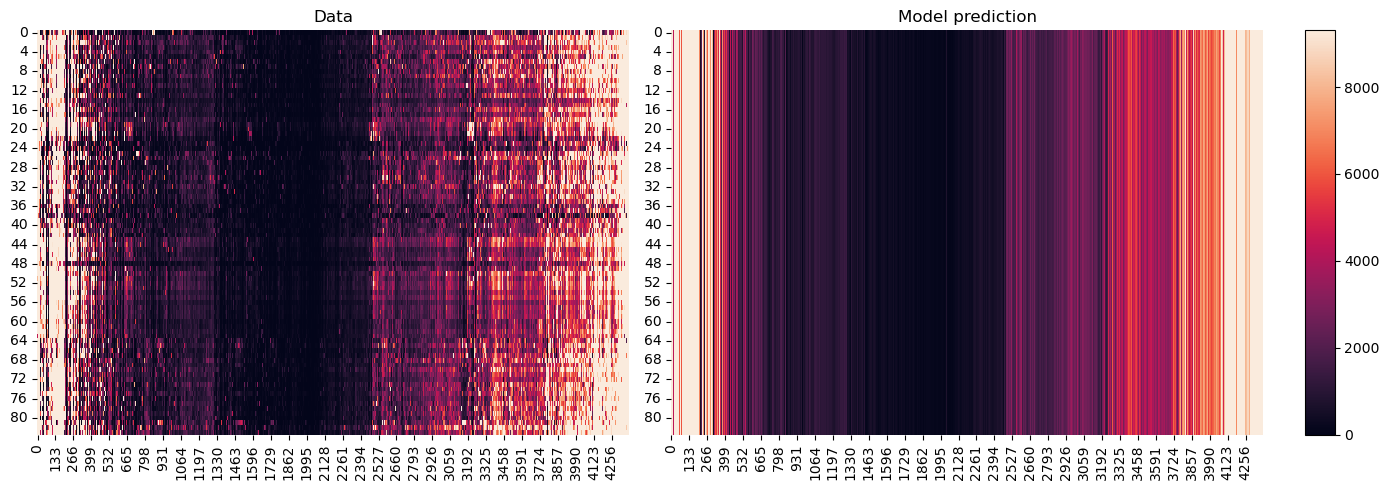

In [14]:
x_in = trainer.test_values['x']
x_out = trainer.test_values['x_recon']

# Cluster rows
row_linkage = sch.linkage(x_in, method='average')
row_dendro = sch.dendrogram(row_linkage, no_plot=True)
row_order = row_dendro['leaves']

# Cluster columns
col_linkage = sch.linkage(x_in.T, method='average')
col_dendro = sch.dendrogram(col_linkage, no_plot=True)
col_order = col_dendro['leaves']

# Reorder
x_in = x_in[np.ix_(row_order, col_order)]
x_out = x_out[np.ix_(row_order, col_order)]

# Set up a gridspec layout: 1 row, 3 columns
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05])

# Create subplots according to gridspec
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

# Common color scale
vmin = 0
vmax = np.percentile(x_in, 90)

# Plot heatmaps
sns.heatmap(x_in, ax=ax0, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
ax0.set_title('Data')
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)

sns.heatmap(x_out, ax=ax1, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
ax1.set_title('Model prediction')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Shared colorbar
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="rocket", norm=norm)
sm.set_array([])

fig.colorbar(sm, cax=cax, orientation='vertical')

plt.tight_layout()
plt.show()

---

In [15]:
import numpy as np

glm = m.NBGLM(
    in_features=brca.num_node_features,
    out_features=brca.num_nodes,
    use_covariates=False
)

loader = t.Loader(
    dataset=_dataset,
    generator=generator,
    batch_size=128
)

trainer = t.NBTrainer(
    model=glm,
    loader=loader,
    num_epochs=300,
    loss_fn=t.NBLoss(),
    # optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={'lr':5e-3},
    verbose=True,
    report_metrics=['loss', 'mae', 'rmse']
)

display(trainer.test_metrics)

for i in ['mu','theta']:
    for k,v in {'mean':np.mean, 'std':np.std, 'min':np.min, 'max':np.max}.items():
        print(f'({i}) {k}: {v(trainer.test_values[i])}')

100%|██████████| 300/300 [00:14<00:00, 20.42it/s, Epoch 299     Train: loss=8.2030    mae=1.2752    rmse=2.7103        Val: loss=8.1546    mae=1.2631    rmse=2.7005]

Test	 loss=8.1502    mae=1.2305    rmse=2.5751



{'loss': 8.150187492370605,
 'mean': 0.773764967918396,
 'std': 2.456130027770996,
 'mae': 1.2304884195327759,
 'mse': 6.6312713623046875,
 'rmse': 2.5751254558563232,
 'r2': -0.2574497163295746}

(mu) mean: 4345.03857421875
(mu) std: 8441.4560546875
(mu) min: 30.207317352294922
(mu) max: 87105.7265625
(theta) mean: 2.512376546859741
(theta) std: 1.7399290800094604
(theta) min: 0.15978585183620453
(theta) max: 31.845298767089844


In [16]:
glm._is_trained

False

In [17]:
glm(_batch)['mu'] == trainer.model(_batch)['mu']

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]], device='cuda:1')

In [18]:
trainer.model._is_trained

True

In [19]:
trainer.model(_batch)['mu']

tensor([[ 2176.0635,  4333.7871,  1715.0277,  ...,  3697.6553, 10120.0596,
          1410.3701],
        [ 2176.0635,  4333.7871,  1715.0277,  ...,  3697.6553, 10120.0596,
          1410.3701],
        [ 2176.0635,  4333.7871,  1715.0277,  ...,  3697.6553, 10120.0596,
          1410.3701],
        ...,
        [ 2176.0635,  4333.7871,  1715.0277,  ...,  3697.6553, 10120.0596,
          1410.3701],
        [ 2176.0635,  4333.7871,  1715.0277,  ...,  3697.6553, 10120.0596,
          1410.3701],
        [ 2176.0635,  4333.7871,  1715.0277,  ...,  3697.6553, 10120.0596,
          1410.3701]], device='cuda:1', grad_fn=<ExpBackward0>)

In [20]:
glm == trainer.model

False